In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
df=pd.read_csv('train.csv')
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [3]:
df.shape

(1458644, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [5]:
df.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
std,4.987772e-01,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03
min,1.000000e+00,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

,0
id,0
vendor_id,0
pickup_datetime,0
dropoff_datetime,0
passenger_count,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
store_and_fwd_flag,0


In [8]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])

In [9]:
df['pickup_day']=df['pickup_datetime'].dt.dayofweek

In [10]:

# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

print("Numeric columns:", list(numeric_cols))
print("Categorical columns:", list(categorical_cols))



Numeric columns: ['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'trip_duration']
Categorical columns: ['id', 'store_and_fwd_flag']


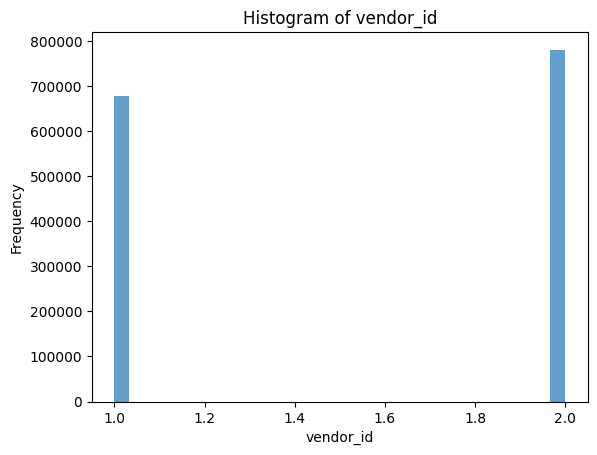

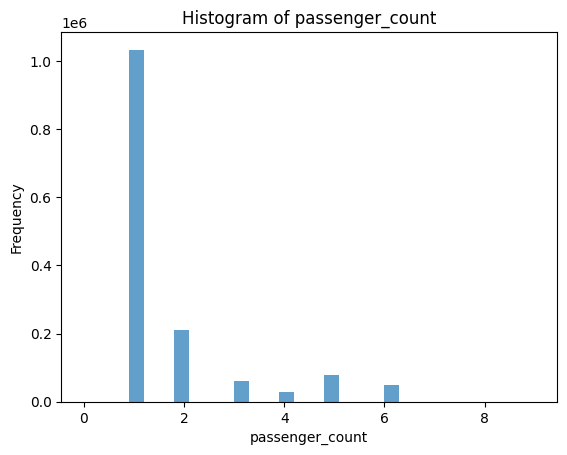

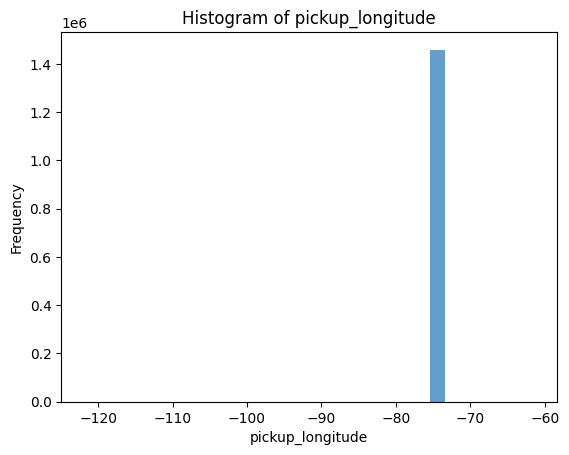

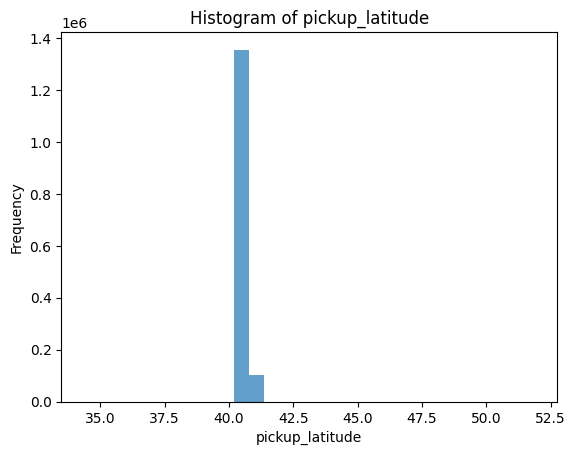

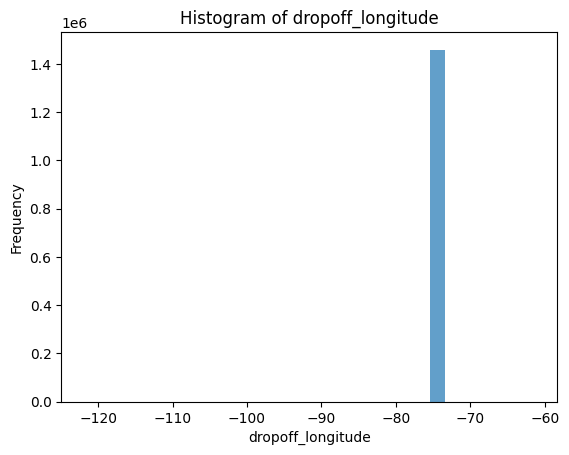

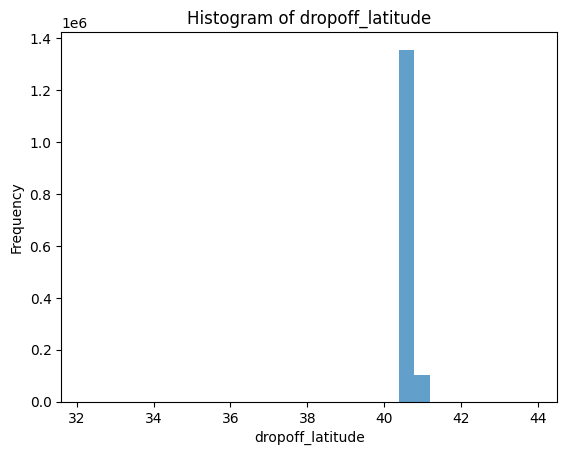

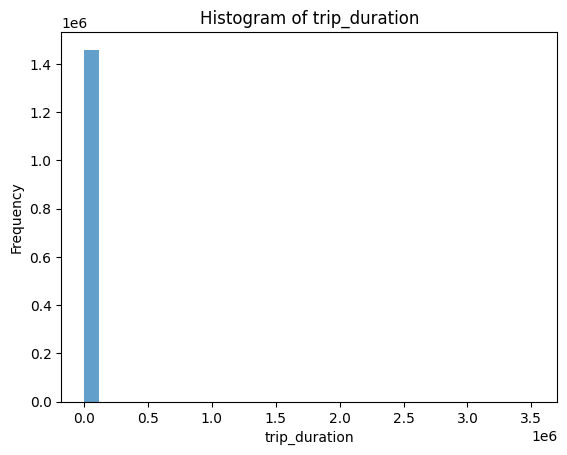

In [11]:
#Histogram for numeric columns
for col in numeric_cols:
    plt.figure()
    df[col].plot(kind='hist', bins=30, alpha=0.7)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.show()


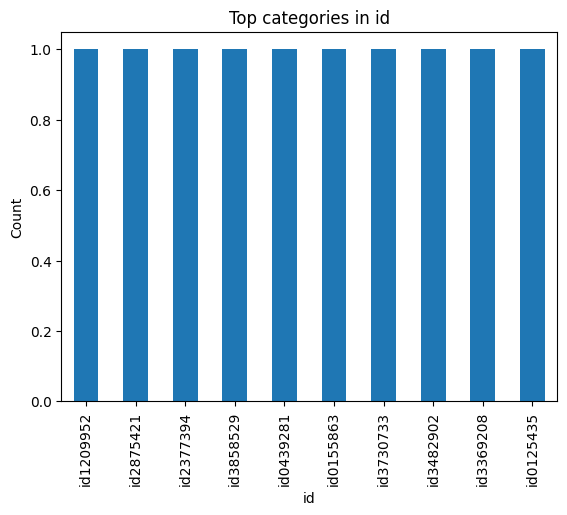

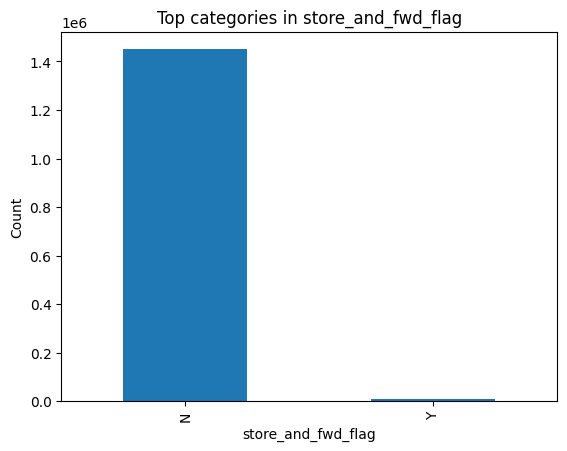

In [12]:
#Bar chart for categorical columns
for col in categorical_cols:
    plt.figure()
    df[col].value_counts().head(10).plot(kind='bar')
    plt.title(f"Top categories in {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()



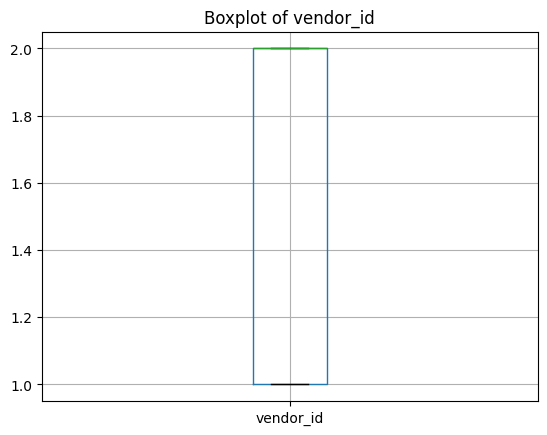

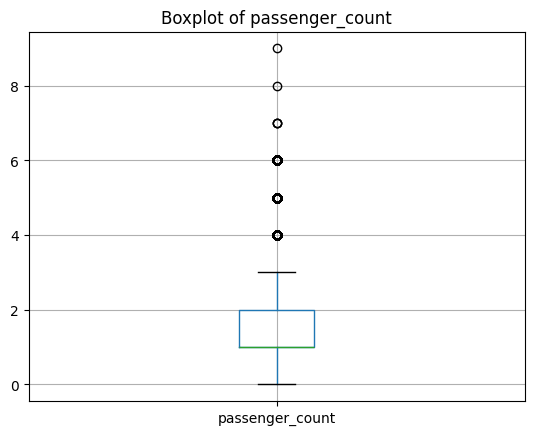

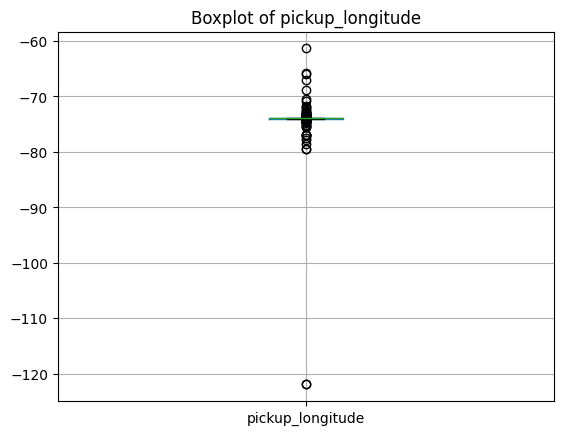

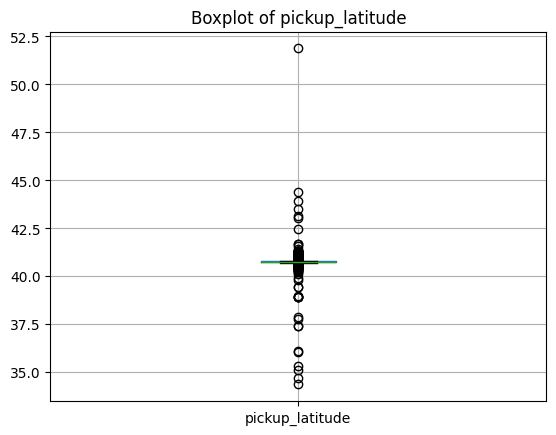

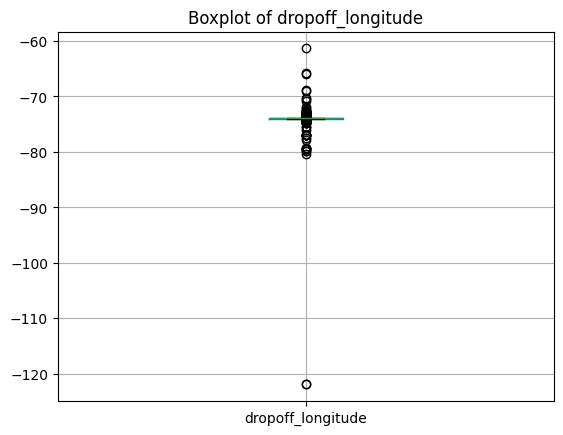

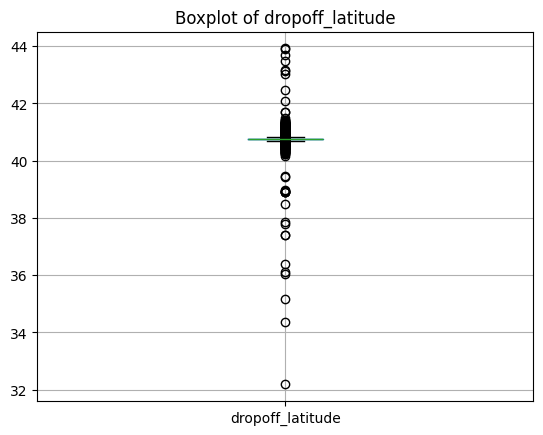

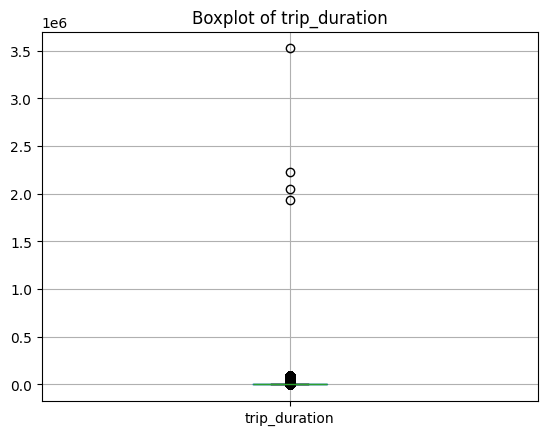

In [13]:

#Boxplot for numeric columns
for col in numeric_cols:
    plt.figure()
    df.boxplot(column=col)
    plt.title(f"Boxplot of {col}")
    plt.show()


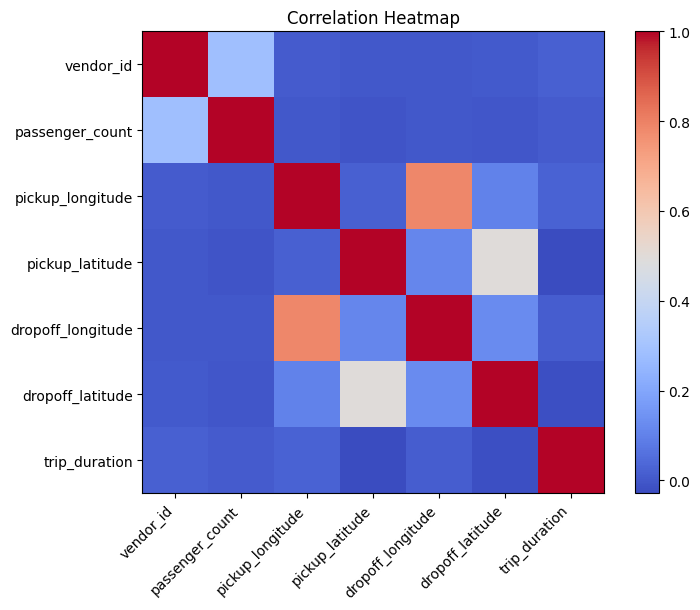

In [14]:

    corr = df[numeric_cols].corr()
    plt.figure(figsize=(8,6))
    plt.imshow(corr, cmap="coolwarm", interpolation="none")
    plt.colorbar()
    plt.xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr)), corr.columns)
    plt.title("Correlation Heatmap")
    plt.show()


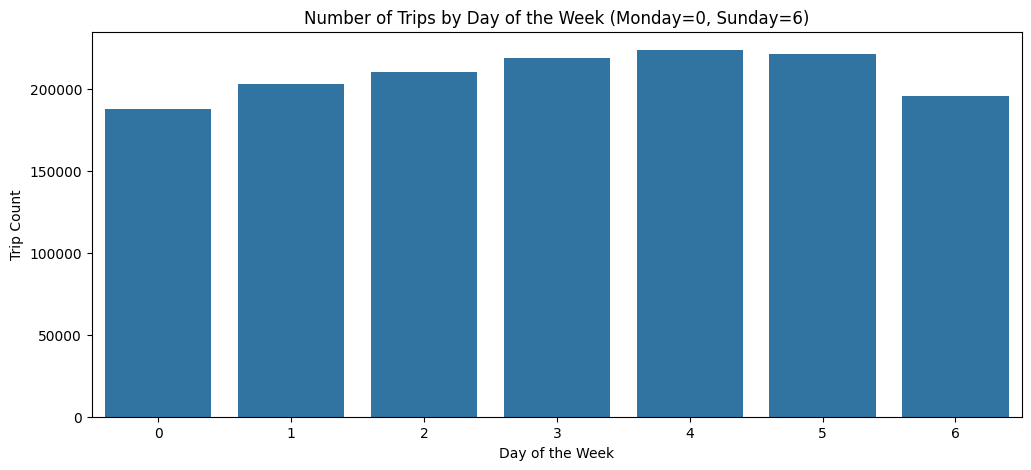

In [20]:
plt.figure(figsize=(12, 5))
sns.countplot(x='pickup_day', data=df)
plt.title('Number of Trips by Day of the Week (Monday=0, Sunday=6)')
plt.xlabel('Day of the Week')
plt.ylabel('Trip Count')
plt.show()


In [15]:
y=df['trip_duration']
x = df.drop('trip_duration', axis=1)

categorical_cols = x.select_dtypes(include=['object']).columns
numerical_cols = x.select_dtypes(include=[np.number]).columns
print(f"\nCategorical columns: {list(categorical_cols)}")
print(f"Numerical columns: {list(numerical_cols)}")


Categorical columns: ['id', 'store_and_fwd_flag']
Numerical columns: ['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'pickup_day']


--- Visualizing Outliers Before Removal (based on IQR) ---

Column 'trip_duration' has 74220 outliers (based on IQR). Plotting...


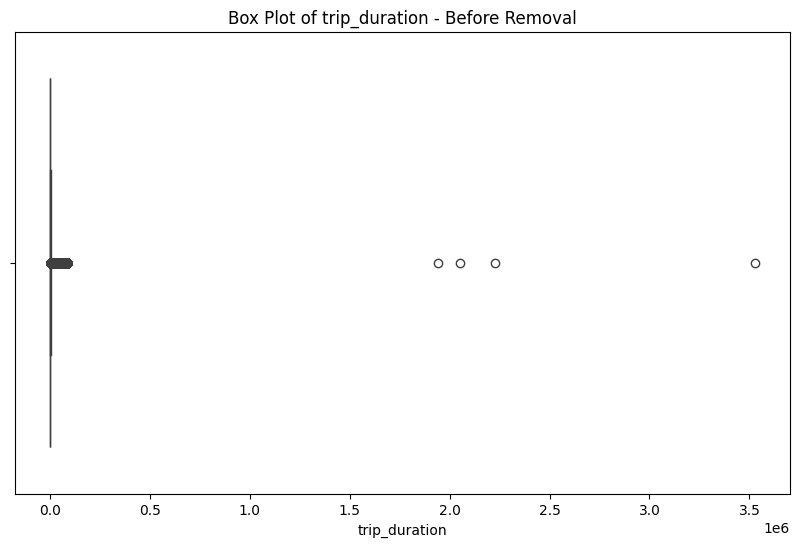


Column 'haversine_distance' has 140673 outliers (based on IQR). Plotting...


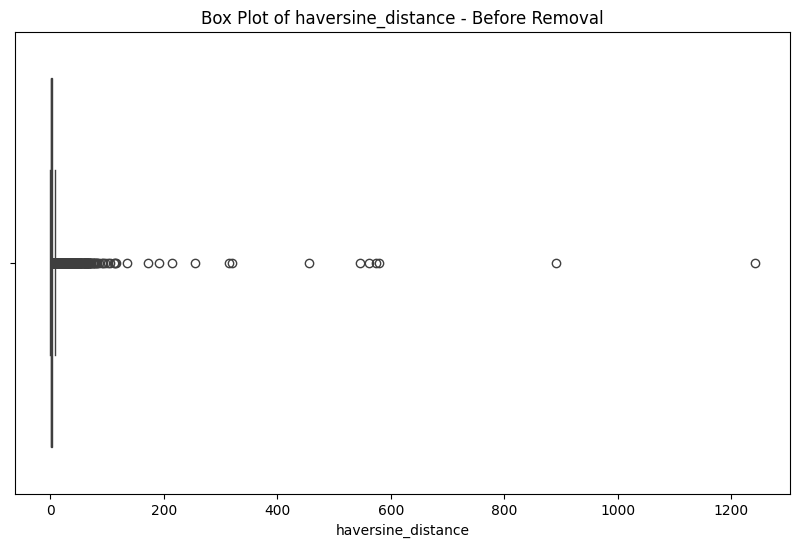


Column 'speed' has 59657 outliers (based on IQR). Plotting...


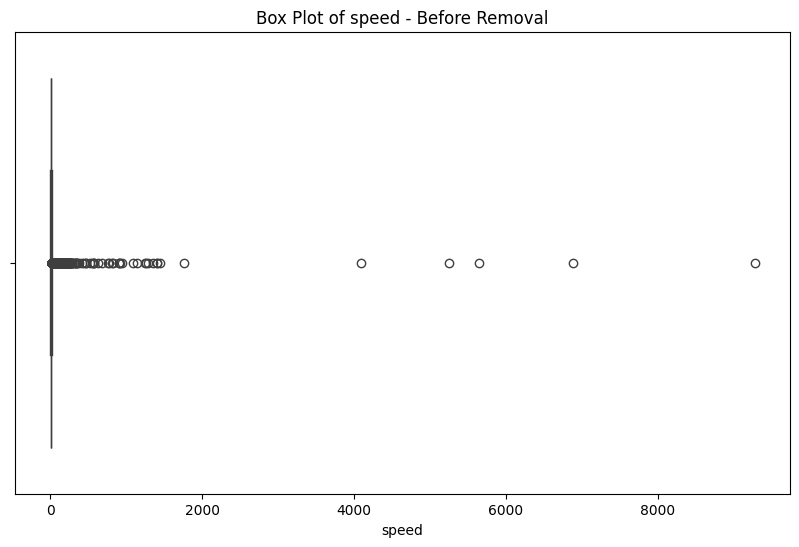


Column 'passenger_count' has 154830 outliers (based on IQR). Plotting...


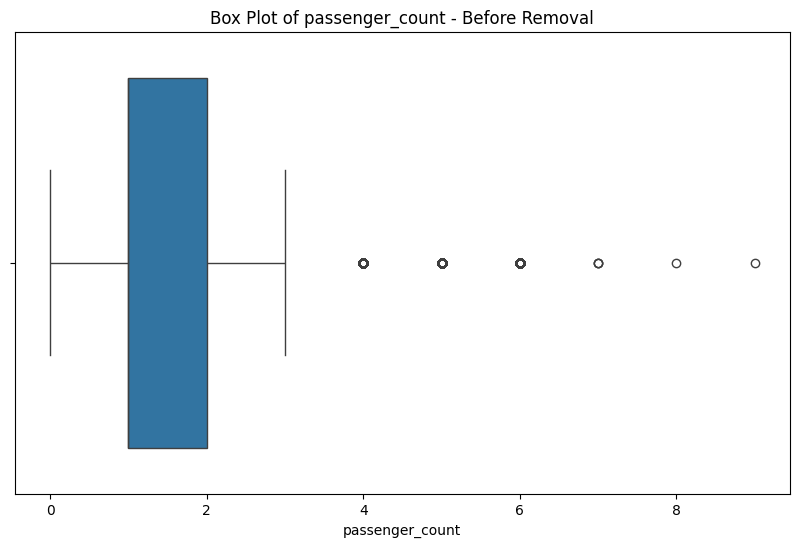


--- Removing Outliers Based on IQR Bounds ---
Original data shape: (1458644, 15)
Data shape after removing outliers (IQR): (1106214, 15)

--- Visualizing Data After IQR Removal ---


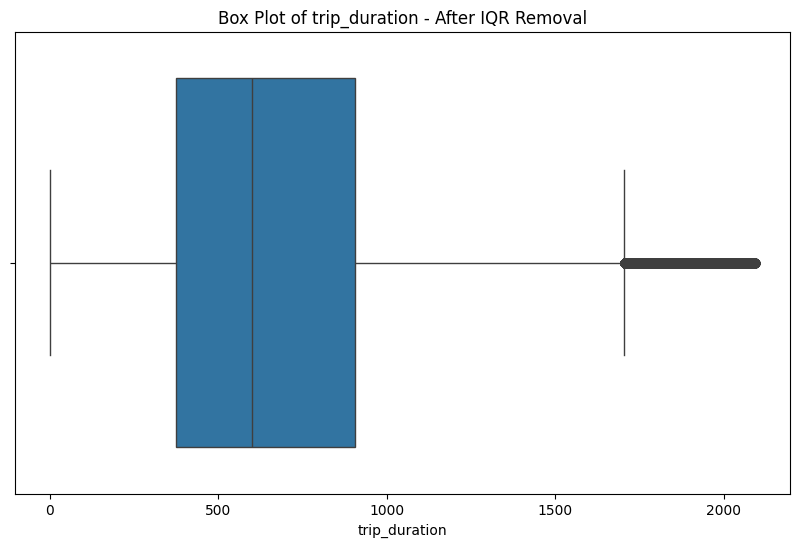

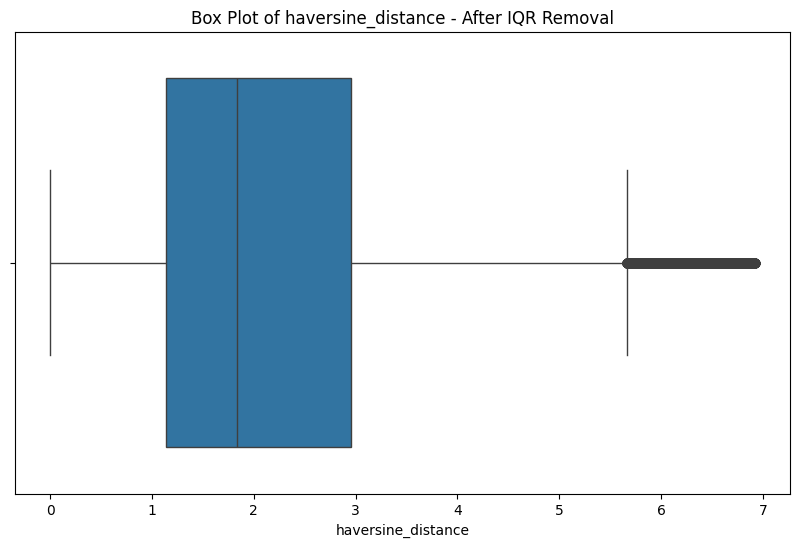

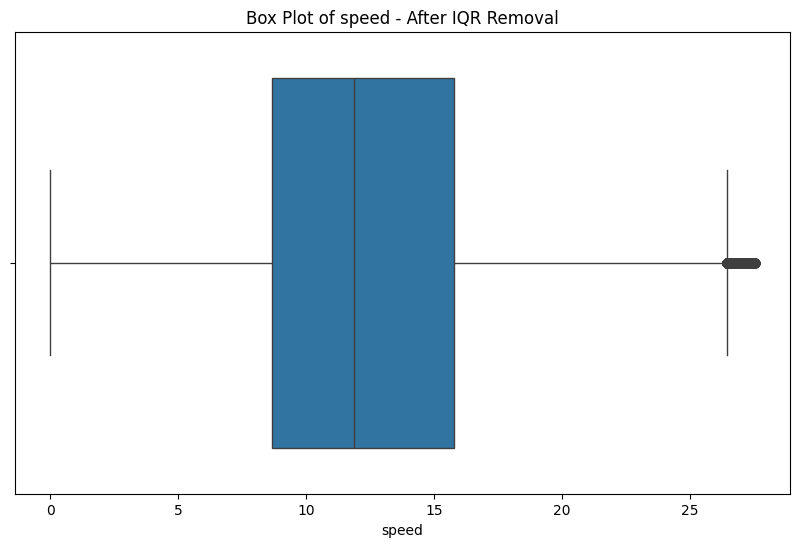

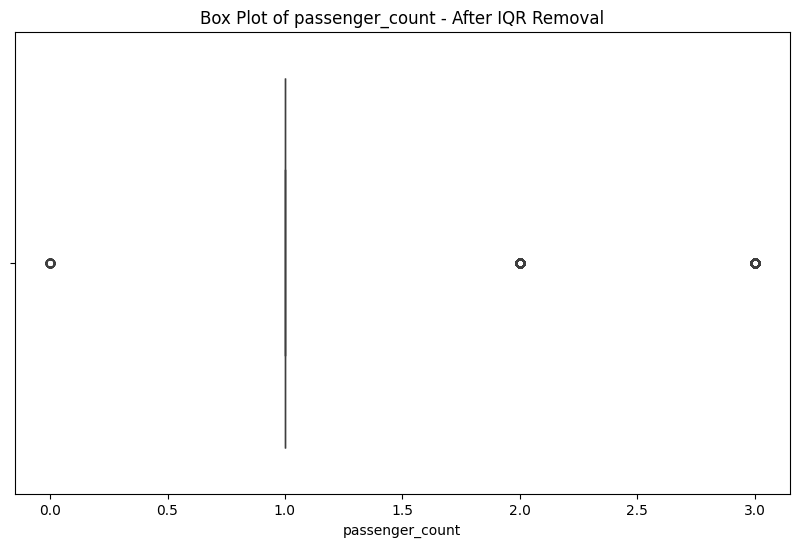

In [25]:
# Calculate haversine distance
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers
    lat1_rad = np.radians(lat1)
    lon1_rad = np.radians(lon1)
    lat2_rad = np.radians(lat2)
    lon2_rad = np.radians(lon2)

    dlon = lon2_rad - lon1_rad
    dlat = lat2_rad - lat1_rad

    a = np.sin(dlat / 2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    distance = R * c
    return distance

df['haversine_distance'] = df.apply(lambda row: haversine(row['pickup_latitude'], row['pickup_longitude'], row['dropoff_latitude'], row['dropoff_longitude']), axis=1)

# Calculate speed in km/h
# Convert trip_duration from seconds to hours
df['speed'] = (df['haversine_distance'] / (df['trip_duration'] / 3600))

columns_to_check = ['trip_duration', 'haversine_distance', 'speed', 'passenger_count']

# --- Step 1: Find and Plot Outliers based on IQR ---
print("--- Visualizing Outliers Before Removal (based on IQR) ---")

df_cleaned_iqr = df.copy() # Create a copy for IQR cleaning

for col in columns_to_check:
    Q1 = df_cleaned_iqr[col].quantile(0.25)
    Q3 = df_cleaned_iqr[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = df_cleaned_iqr[(df_cleaned_iqr[col] < lower_bound) | (df_cleaned_iqr[col] > upper_bound)].shape[0]

    if outlier_count > 0:
        print(f"\nColumn '{col}' has {outlier_count} outliers (based on IQR). Plotting...")
        plt.figure(figsize=(10, 6))
        sns.boxplot(x=df_cleaned_iqr[col])
        plt.title(f'Box Plot of {col} - Before Removal')
        plt.show()

# --- Step 2: Handle Outliers by Removal using IQR Bounds ---
print("\n--- Removing Outliers Based on IQR Bounds ---")
print(f"Original data shape: {df.shape}")

# Apply IQR based removal rules
for col in columns_to_check:
    Q1 = df_cleaned_iqr[col].quantile(0.25)
    Q3 = df_cleaned_iqr[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_cleaned_iqr = df_cleaned_iqr[(df_cleaned_iqr[col] >= lower_bound) & (df_cleaned_iqr[col] <= upper_bound)]

print(f"Data shape after removing outliers (IQR): {df_cleaned_iqr.shape}")


# --- Step 3: Visualize the CLEANED Data (after IQR removal) ---
print("\n--- Visualizing Data After IQR Removal ---")

for col in columns_to_check:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df_cleaned_iqr[col])
    plt.title(f'Box Plot of {col} - After IQR Removal')
    plt.show()


In [31]:
df=df_cleaned_iqr

In [32]:

# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

print("Numeric columns:", list(numeric_cols))
print("Categorical columns:", list(categorical_cols))


Numeric columns: ['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'trip_duration', 'haversine_distance', 'speed']
Categorical columns: ['id', 'store_and_fwd_flag']


In [33]:
xp = x.copy()
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    xp[col] = le.fit_transform(xp[col].astype(str))
    label_encoders[col] = le

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    xp, y, test_size=0.2, random_state=42
)

In [39]:
df_cleaned = df_cleaned_iqr.copy()

target_column = "trip_duration"

X = df_cleaned.drop(columns=[target_column, 'id', 'pickup_datetime', 'dropoff_datetime']) # Drop 'id' and datetime columns
y = df_cleaned[target_column]

numerical_cols = X.select_dtypes(include=np.number).columns
categorical_cols = X.select_dtypes(include='object').columns

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale numerical features
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])


models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=42),
    "Lasso Regression": Lasso(alpha=0.1, random_state=42)
}

results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)

    train_r2 = r2_score(y_train, y_pred_train)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))

    y_pred_test = model.predict(X_test)
    test_r2 = r2_score(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))


    results.append({
        "Model": name,
        "Train R²": round(train_r2, 4),
        "Train RMSE": round(train_rmse, 4),
        "Test R²": round(test_r2, 4),
        "Test RMSE": round(test_rmse, 4)
    })

results_df = pd.DataFrame(results)
print("\nModel Performance Comparison:")
print(results_df)


Training Linear Regression...

Training Ridge Regression...

Training Lasso Regression...

Model Performance Comparison:
               Model  Train R²  Train RMSE  Test R²  Test RMSE
0  Linear Regression    0.8374    160.6402   0.8371   160.5236
1   Ridge Regression    0.8374    160.6402   0.8371   160.5236
2   Lasso Regression    0.8374    160.6443   0.8371   160.5267
